In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

4.23

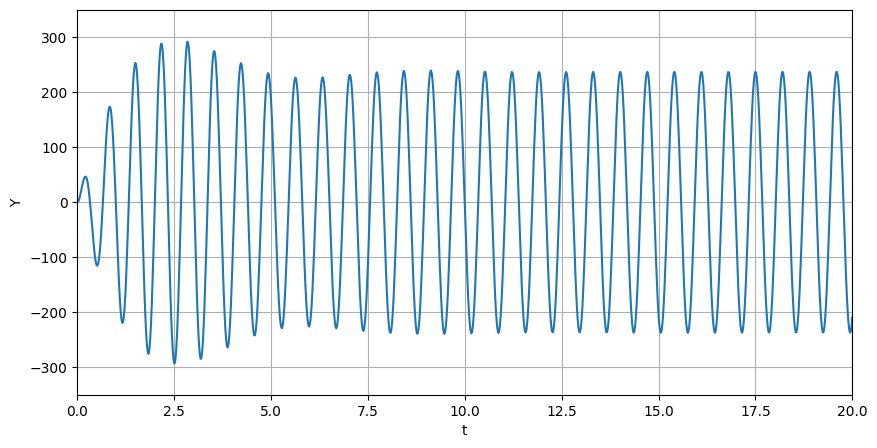

In [2]:
def ode_model(t, y, w0, gam, f0, wd):
    x, v = y
    dxdt = v
    dvdt = f0 * np.cos(wd * t) - gam * v - w0**2 * x
    return [dxdt, dvdt]

m = 1.0
k = 100.0
alpha = 1.0
f_amp = 5000.0
w_drive = 9.0

w0 = np.sqrt(k / m)
gam = alpha / m
f0 = f_amp / m
wd = w_drive

y0 = [0.0, 0.0]

t_start = 0.0
t_end = 20.0
t_eval_points = np.linspace(t_start, t_end, 1000)

sol = solve_ivp(
    ode_model,
    [t_start, t_end],
    y0,
    args=(w0, gam, f0, wd),
    t_eval=t_eval_points,
    dense_output=False,
    method='RK45'
)

t = sol.t
x = sol.y[0]

plt.figure(figsize=(10, 5))
plt.plot(t, x)
plt.xlabel('t')
plt.ylabel('Y')
plt.grid(True)
plt.ylim([-350, 350])
plt.xlim([t_start, t_end])
plt.show()

6.13

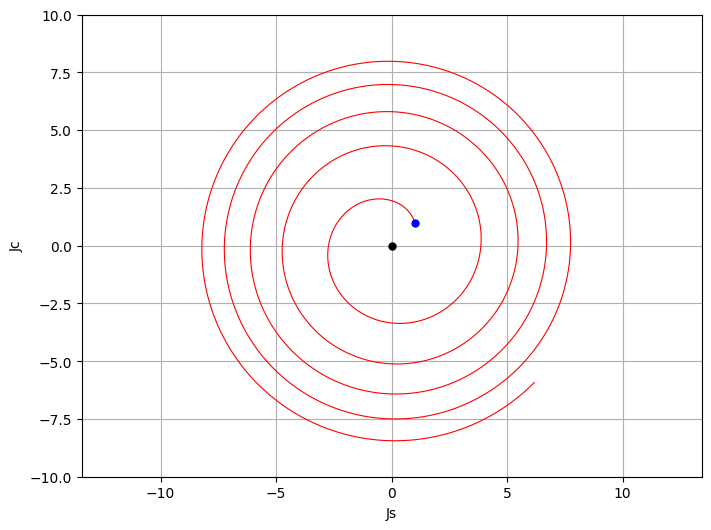

In [3]:
def param_ode(t, y, w, delta, gamma, alpha, beta):
    js, jc = y
    js2_jc2 = js**2 + jc**2
    bracket = alpha + (3/4) * beta * js2_jc2
    djsdt = (w / 2) * ( (gamma - delta) * js - bracket * jc )
    djcdt = (w / 2) * ( (gamma - delta) * jc + bracket * js )
    return [djsdt, djcdt]

w = 2.0      # w
alpha = 0.01 # a
beta = 0.1   # b
delta = 0.01 # c (δ)
gamma = 0.1  # d (γ)

y0 = [1.0, 1.0] # Js[0]=1, Jc[0]=1

t_start = 0.0
t_end = 20.0
t_eval = np.linspace(t_start, t_end, 10000)

sol = solve_ivp(
    param_ode,
    [t_start, t_end],
    y0,
    args=(w, delta, gamma, alpha, beta),
    t_eval=t_eval,
    method='RK45',
    rtol=1e-6,
    atol=1e-9
)

js_vals = sol.y[0]
jc_vals = sol.y[1]

plt.figure(figsize=(8, 6))
plt.plot(js_vals, jc_vals, 'r-', linewidth=0.8)
plt.xlabel('Js')
plt.ylabel('Jc')
plt.grid(True)
plt.axis('equal')
plt.xlim([-10.0, 10.0])
plt.ylim([-10.0, 10.0])
plt.plot(y0[0], y0[1], 'bo', markersize=5, label='Start (1,1)')
plt.plot(0, 0, 'ko', markersize=5, label='Origin (0,0)')
plt.show()